
## 🧠 Data Engineering ETL Project: Building a Data Pipeline from Multiple Sources

### 🎯 Project Overview
This project demonstrates the creation of an **Extract, Transform, Load (ETL)** pipeline using **Python**.  
The pipeline integrates multi-source data — combining structured data from a CSV file with semi-structured data retrieved from a public API (restcountries) — to produce a unified dataset for analytics and reporting.

---

## 📂 Data Sources

### 1️⃣ CSV Data — `all_countries.csv`
This dataset contains information about countries worldwide, including:
- Country Name  
- Region  
- Population  
- GDP per capita  
- Area (sq. km)  

📥 **Source:**  
- Using the option of **Any Public API** of the restcountries from  https://www.datacamp.com/workspace/external-link?url=https%3A%2F%2Frestcountries.com%2Fv3.1%2Fregion%2Fafrica%3Ffields%3Dname%2Ccapital%2Ccontinents providing country-level metrics (economic, demographic, environmental, etc.)

---

This script shows an end-to-end ETL (Extract, Transform, Load) process that:

1. Extracts live JSON data from the World Bank API.
2. Cleans and transforms a provided countries dataset.
3. Merges both datasets into a unified analytical view.
4. Exports outputs and basic analysis summaries.

It is designed to be modular, reusable, and ready for integration into a data
engineering pipeline.


In [1]:
# import requests and other packages needed
import requests
import pandas as pd
import json
import time
import numpy as np
import matplotlib.pyplot as plt

## Configurations for Data Input and Output

In [2]:
CSV_PATH = "all_countries.csv"

# REST Countries endpoint: one request only, with selected fields to keep payload small

API_URL = (
    "https://restcountries.com/v3.1/all"
    "?fields=cca3,name,region,subregion,area,population,capital,latlng"
)

RAW_JSON_OUT = "extracted_api.json"
TRANSFORMED_CSV_OUT = "transformed_api.csv"
MERGED_CSV_OUT = "merged_countries.csv"

MAX_RETRIES = 2         # gentle retries on transient errors
BASE_SLEEP  = 1.5       # exponential backoff base (1.5s, then 3.0s)

## 1. Data Extraction Function

Extract indicator data for all countries from the RESTCOUNTRIES API.

In [3]:
def load_csv(path: str) -> pd.DataFrame:
    """
    Read the project CSV and normalize column names.
    Ensures 'iso3' exists and is uppercase for merging.
    """
    df = pd.read_csv(path)
    df.columns = (
        df.columns.str.strip()
                  .str.lower()
                  .str.replace(r"[^\w]+", "_", regex=True)
                  .str.strip("_")
    )
    if "iso3" not in df.columns:
        raise ValueError("CSV must include an 'iso3' column.")
    df["iso3"] = df["iso3"].astype(str).str.upper()
    return df.drop_duplicates(subset=["iso3"], keep="first")


def fetch_restcountries_all(url: str, max_retries: int = 2, base_sleep: float = 1.5) -> list[dict] | None:
    """
    Single HTTP GET to REST Countries. Retries politely on transient failures.
    Returns a Python list of country dicts, or None if it still fails.
    """
    attempt = 0
    while True:
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            payload = r.json()
            if not isinstance(payload, list):
                # unexpected shape
                return []
            return payload
        except requests.HTTPError as e:
            attempt += 1
            status = getattr(e.response, "status_code", None)
            # If rate-limited (rare here), or other transient error, try a brief backoff
            if attempt <= max_retries and status in (429, 500, 502, 503, 504):
                retry_after = e.response.headers.get("Retry-After")
                sleep_s = float(retry_after) if retry_after else base_sleep * (2 ** (attempt - 1))
                print(f"HTTP {status}. Sleeping {sleep_s:.1f}s then retrying ({attempt}/{max_retries})...")
                time.sleep(sleep_s)
                continue
            print(f"API failed with HTTP {status}. Proceeding without API.")
            return None
        except requests.RequestException as e:
            attempt += 1
            if attempt <= max_retries:
                sleep_s = base_sleep * (2 ** (attempt - 1))
                print(f"Network error: {e}. Sleeping {sleep_s:.1f}s then retrying ({attempt}/{max_retries})...")
                time.sleep(sleep_s)
                continue
            print("Network still failing. Proceeding without API.")
            return None

## 2. Transformation

Cleans and standardizes both datasets to ensure consistency in schema and data types.
Handles missing values and renames overlapping columns for merging.


In [4]:
def tidy_restcountries(payload: list[dict]) -> pd.DataFrame:
    """
    Flatten a subset of REST Countries fields into a tidy DataFrame.
    Output columns:
      - iso3
      - name_common
      - region
      - subregion
      - area
      - population
      - capital_0 (first capital if list exists)
      - lat, lng (first two coords if present)
    """
    if not payload:
        return pd.DataFrame(columns=[
            "iso3","name_common","region","subregion","area","population","capital_0","lat","lng"
        ])

    rows = []
    for c in payload:
        cca3 = c.get("cca3")  # ISO-3
        if not isinstance(cca3, str):
            continue

        # name.common is nested
        name_obj = c.get("name") or {}
        name_common = name_obj.get("common")

        region = c.get("region")
        subregion = c.get("subregion")
        area = c.get("area")
        population = c.get("population")

        # capital may be a list
        cap_list = c.get("capital") or []
        capital_0 = cap_list[0] if isinstance(cap_list, list) and cap_list else None

        # latlng is a [lat, lng] list
        latlng = c.get("latlng") or []
        lat = latlng[0] if len(latlng) >= 1 else None
        lng = latlng[1] if len(latlng) >= 2 else None

        rows.append({
            "iso3": cca3.upper(),
            "name_common": name_common,
            "region": region,
            "subregion": subregion,
            "area": area,
            "population": population,
            "capital_0": capital_0,
            "lat": lat,
            "lng": lng
        })

    df = pd.DataFrame(rows).drop_duplicates(subset=["iso3"], keep="first")
    # numeric coercion for area/population, just in case
    for c in ["area", "population", "lat", "lng"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


## Loading the Cleaned and Merged Dataset

Loads the cleaned and merged dataset into structured output files.


In [5]:
def save_raw_json(obj, path: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def save_csv(df: pd.DataFrame, path: str) -> None:
    df.to_csv(path, index=False, encoding="utf-8")

def merge_on_iso3(left: pd.DataFrame, right: pd.DataFrame) -> pd.DataFrame:
    return left.merge(right, on="iso3", how="left")


## Putting it all together

In [6]:

def main():
    # Extract: CSV
    print("Loading CSV...")
    df_csv = load_csv(CSV_PATH)

    # Extract: REST Countries (one request)
    print("Fetching REST Countries (single request)...")
    payload = fetch_restcountries_all(API_URL, max_retries=MAX_RETRIES, base_sleep=BASE_SLEEP)

    used_api = payload is not None
    if used_api:
        print(f"API success. Received {len(payload)} country records.")
        save_raw_json(payload, RAW_JSON_OUT)
    else:
        print("API unavailable. Continuing with CSV only.")
        save_raw_json({"note": "API skipped due to error; pipeline continued with CSV only."}, RAW_JSON_OUT)

    # Transform API → tidy DataFrame (may be empty if API failed)
    if used_api:
        df_api = tidy_restcountries(payload)
    else:
        df_api = pd.DataFrame(columns=[
            "iso3","name_common","region","subregion","area","population","capital_0","lat","lng"
        ])

    save_csv(df_api, TRANSFORMED_CSV_OUT)

    # Load: merge
    df_merged = merge_on_iso3(df_csv, df_api)
    save_csv(df_merged, MERGED_CSV_OUT)

    print("\nPreview (merged):")
    print(df_merged.head(10))
    print(f"\nDone. API used: {used_api}. Files written: {RAW_JSON_OUT}, {TRANSFORMED_CSV_OUT}, {MERGED_CSV_OUT}")

if __name__ == "__main__":
    main()

Loading CSV...
Fetching REST Countries (single request)...
API success. Received 250 country records.

Preview (merged):
            country           capital  ...        lat    lng
0         Lithuania           Vilnius  ...  56.000000  24.00
1             Chile          Santiago  ... -30.000000 -71.00
2             Benin        Porto-Novo  ...   9.500000   2.25
3  Falkland Islands           Stanley  ... -51.750000 -59.00
4           Georgia           Tbilisi  ...  42.000000  43.50
5            Cyprus           Nicosia  ...  35.000000  33.00
6             Ghana             Accra  ...   8.000000  -2.00
7           Belgium          Brussels  ...  50.833333   4.00
8              Cuba            Havana  ...  21.500000 -80.00
9           Andorra  Andorra la Vella  ...  42.500000   1.50

[10 rows x 16 columns]

Done. API used: True. Files written: extracted_api.json, transformed_api.csv, merged_countries.csv


## Data Preparation and analysis

In [7]:
# Step 1 — Load the merged dataset
MERGED_CSV_OUT = "merged_countries.csv"

df = pd.read_csv(MERGED_CSV_OUT)
print("✅ Data loaded successfully.")
print(df.info())
print("\nPreview:")
print(df.head())

✅ Data loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       250 non-null    object 
 1   capital       246 non-null    object 
 2   region_x      250 non-null    object 
 3   continents    250 non-null    object 
 4   area_x        250 non-null    float64
 5   population_x  250 non-null    int64  
 6   iso2          249 non-null    object 
 7   iso3          250 non-null    object 
 8   name_common   250 non-null    object 
 9   region_y      250 non-null    object 
 10  subregion     245 non-null    object 
 11  area_y        250 non-null    float64
 12  population_y  250 non-null    int64  
 13  capital_0     246 non-null    object 
 14  lat           250 non-null    float64
 15  lng           250 non-null    float64
dtypes: float64(4), int64(2), object(10)
memory usage: 31.4+ KB
None

Preview:
            co

In [8]:

MERGED_CSV_OUT = "merged_countries.csv"
df = pd.read_csv(MERGED_CSV_OUT)

# Create unified columns picking API values first, falling back to CSV
df["region"] = df.get("region_y").fillna(df.get("region_x"))
df["population"] = pd.to_numeric(df.get("population_y", pd.Series()), errors="coerce")\
                      .fillna(pd.to_numeric(df.get("population_x", pd.Series()), errors="coerce"))
df["area"] = pd.to_numeric(df.get("area_y", pd.Series()), errors="coerce")\
                 .fillna(pd.to_numeric(df.get("area_x", pd.Series()), errors="coerce"))

# Helpful display name: prefer API name_common, else CSV country
df["display_name"] = df.get("name_common").fillna(df.get("country"))

# Optional: quick sanity check
print(df[["display_name","iso3","region","population","area"]].head())


       display_name iso3    region  population      area
0         Lithuania  LTU    Europe     2894886   65300.0
1             Chile  CHL  Americas    20206953  756102.0
2             Benin  BEN    Africa    13224860  112622.0
3  Falkland Islands  FLK  Americas        3662   12173.0
4           Georgia  GEO      Asia     4000921   69700.0


## Analysis 1: Total Population by Region

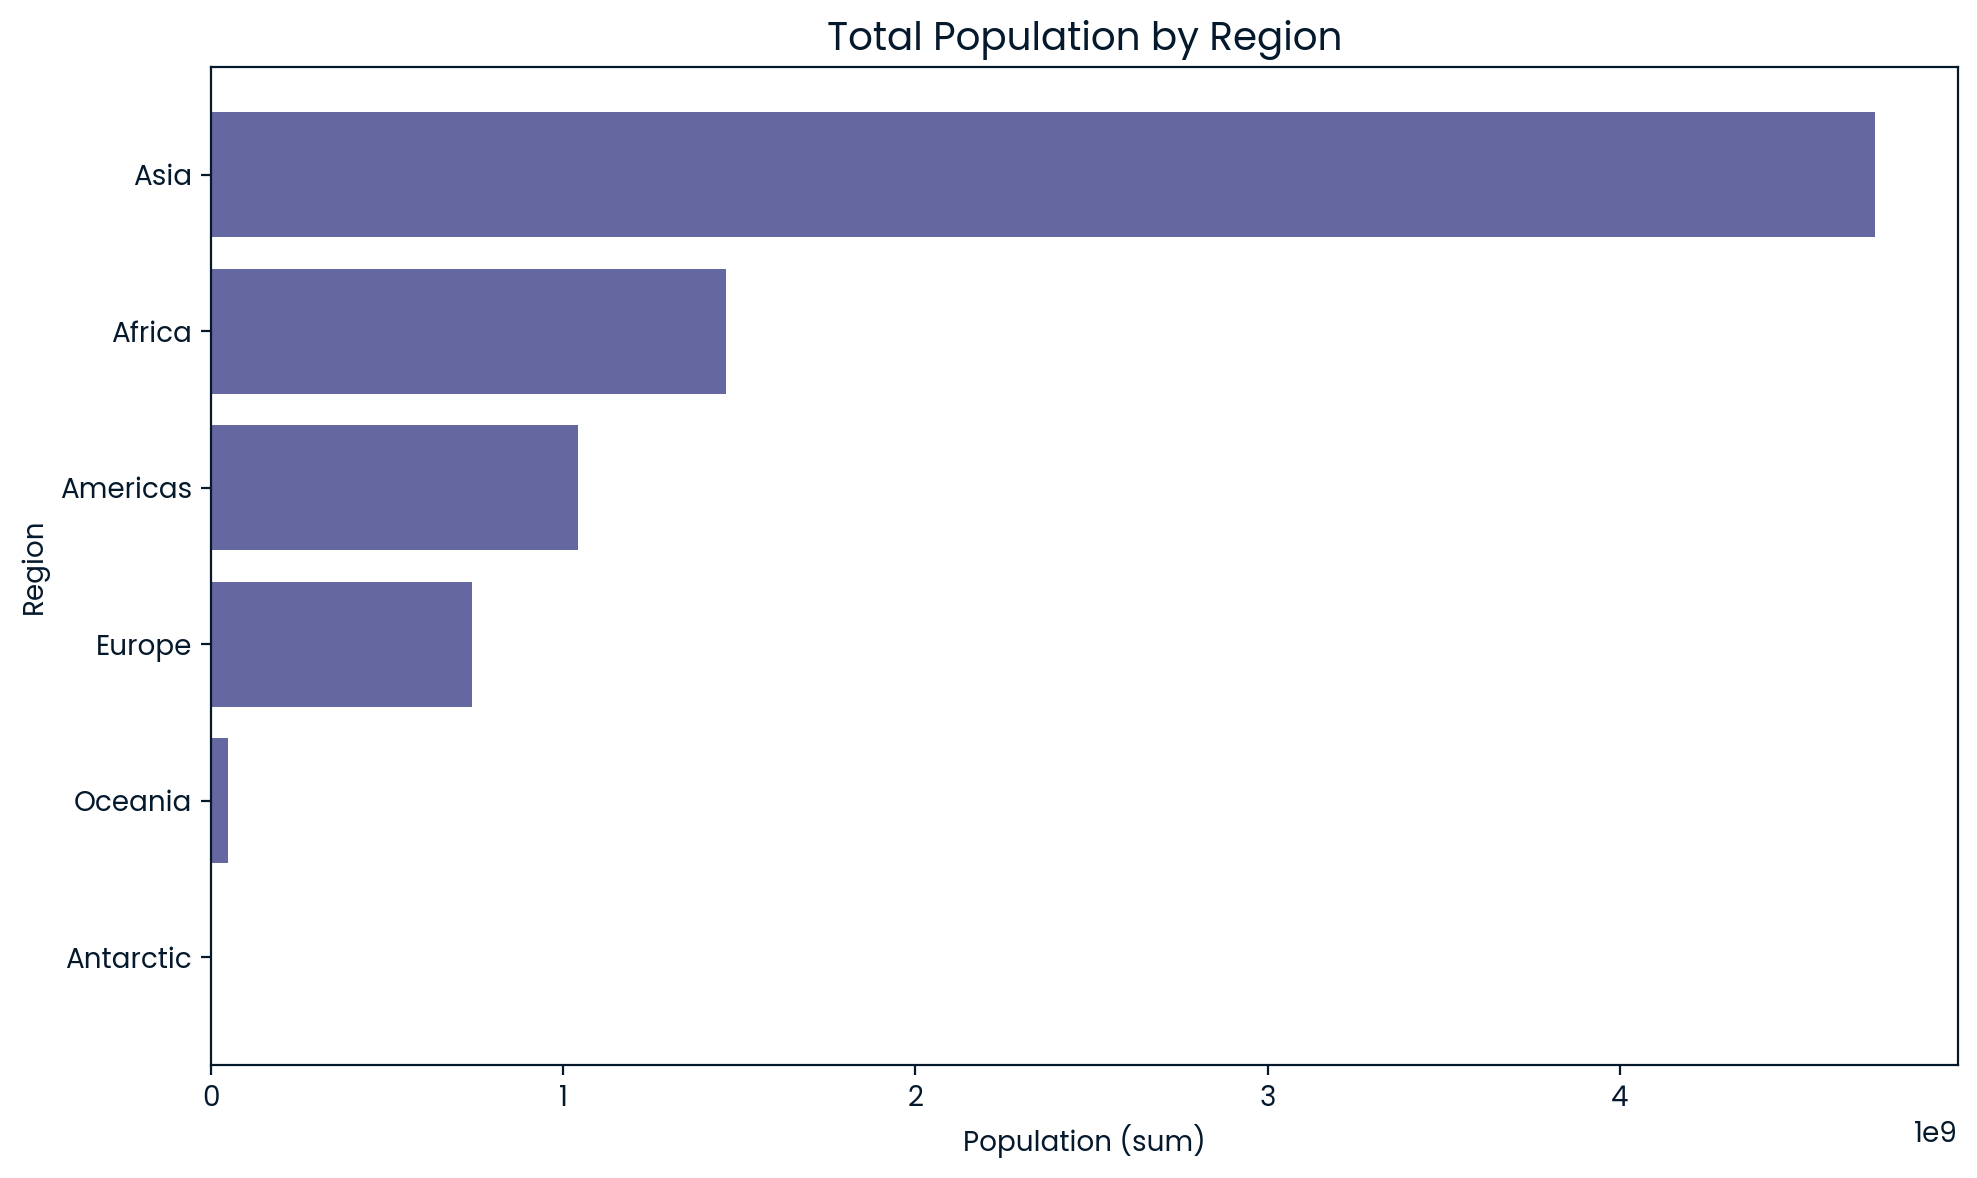

Population by region:
region
Asia         4724731966
Africa       1462464411
Americas     1042579783
Europe        741657922
Oceania        48059678
Antarctic          1700
Name: population, dtype: int64


In [9]:

# Drop rows without region or population
pop_by_region = (
    df.dropna(subset=["region","population"])
      .groupby("region")["population"]
      .sum()
      .sort_values(ascending=False)
)

# Plot (horizontal bar)
plt.figure(figsize=(10,6))
plt.barh(pop_by_region.index, pop_by_region.values)
plt.gca().invert_yaxis()  # biggest at top
plt.title("Total Population by Region", fontsize=14)
plt.xlabel("Population (sum)")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

print("Population by region:")
print(pop_by_region)

## Analysis 2: Country Area by Popuation

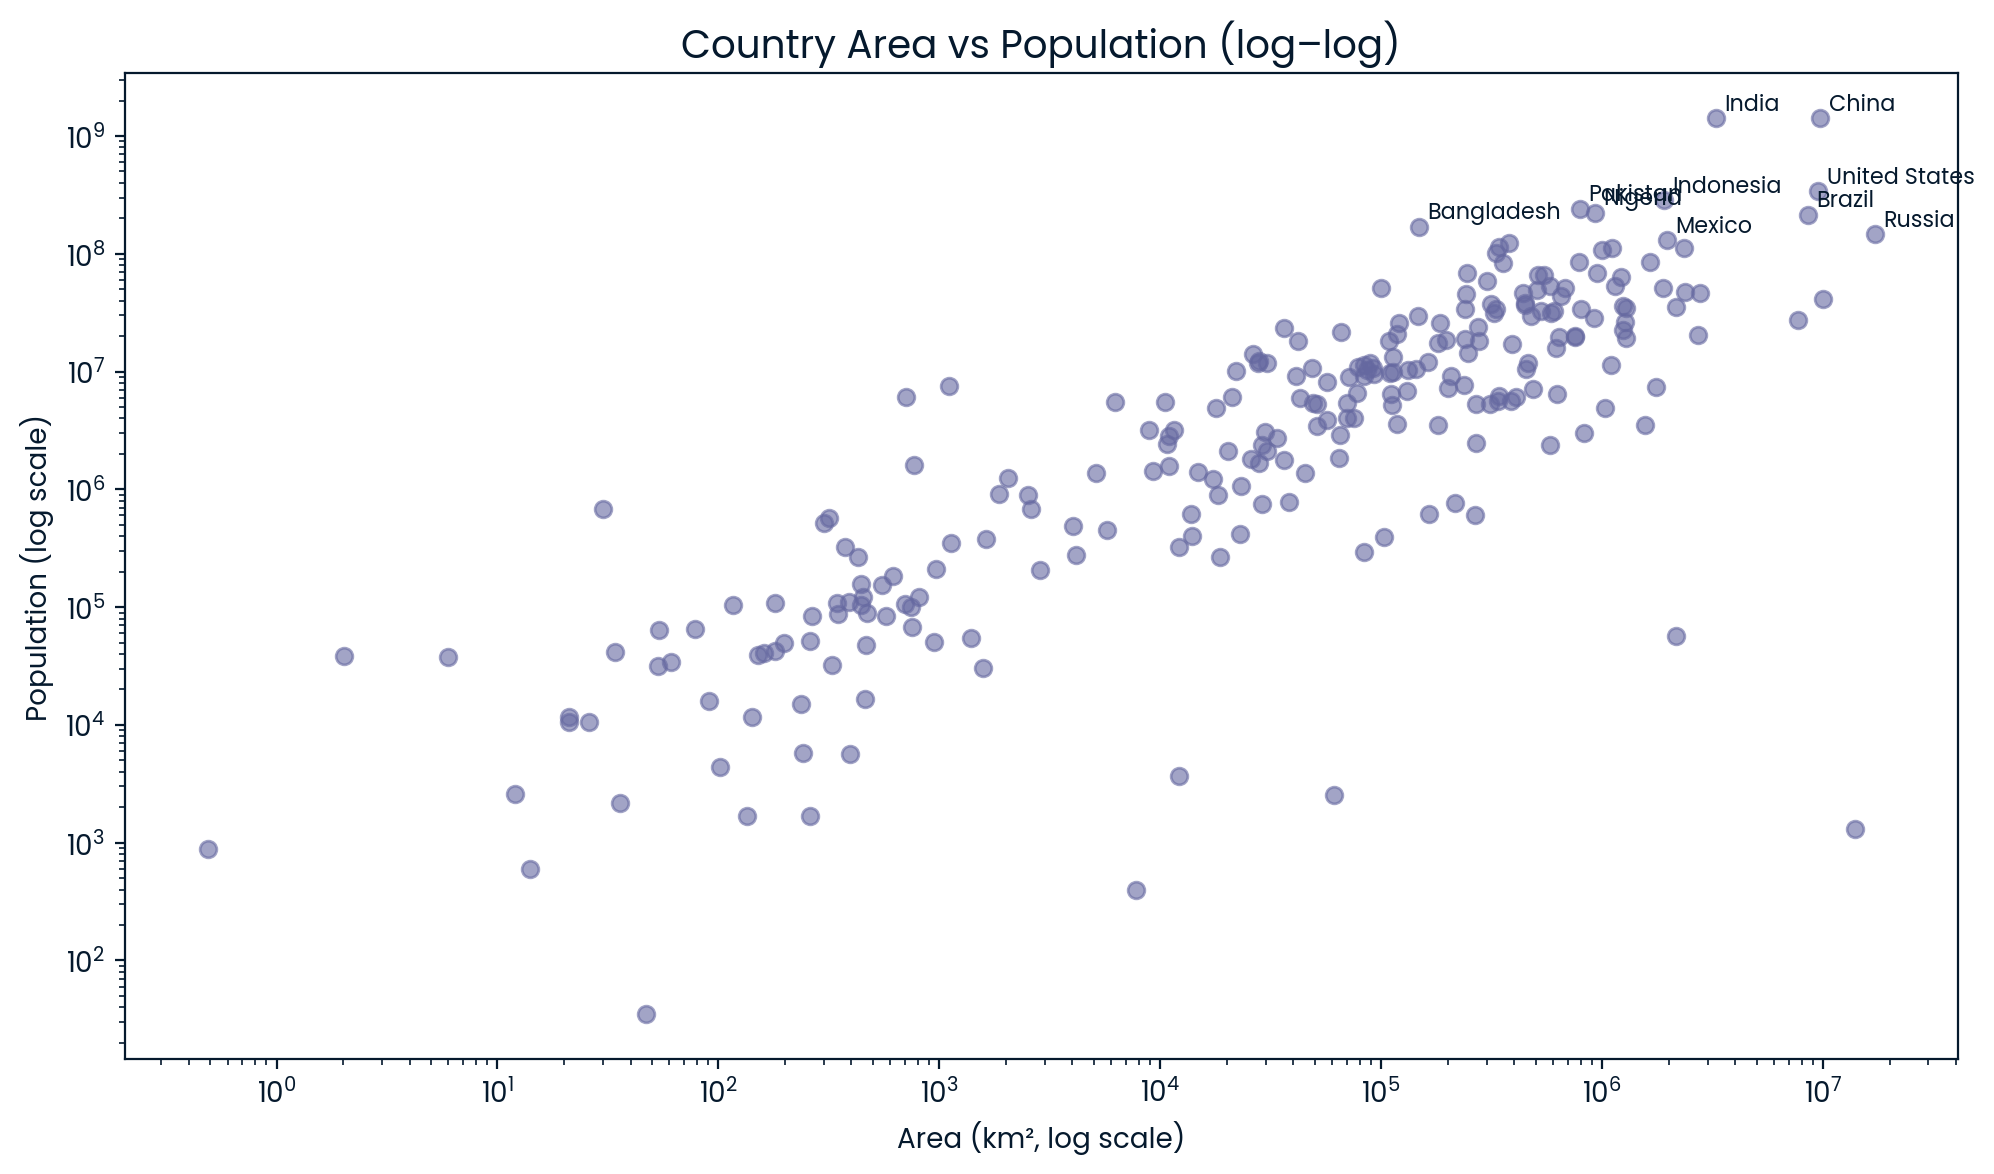

In [10]:

# Keep valid, positive values

mask = (df["area"] > 0) & (df["population"] > 0)
d = df.loc[mask, ["display_name","region","area","population"]].copy()

plt.figure(figsize=(10,6))
plt.scatter(d["area"], d["population"], alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.title("Country Area vs Population (log–log)", fontsize=14)
plt.xlabel("Area (km², log scale)")
plt.ylabel("Population (log scale)")
plt.tight_layout()

# Label the 10 most populous countries to add context
top10 = d.nlargest(10, "population")
for _, r in top10.iterrows():
    plt.annotate(r["display_name"], (r["area"], r["population"]), fontsize=8,
                 xytext=(3,3), textcoords="offset points")

plt.show()
